In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
import optuna
import shap

from catboost import CatBoostRegressor

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

d:\01 Professional software operation\miniconda3\envs\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

folder_path = 'AD-figure'

# 检查文件夹是否存在，如果不存在则创建它
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"文件夹 {folder_path} 已创建。")

In [3]:
# 读取数据，设置指定列的类型
df = pd.read_csv("ADlog_填充.csv",  dtype={'DIPOCE': str, 'BA_Code': str, 'Cata_Code': str})
df

,DIPOCE,DI_NCO,PO_HV,PO_f,BA_Code,BA_Mn,PO_Phr,BA_Phr,FS_Phr,Cata_Phr,...,M_loss,Yield,R,CHS,A_Mix_t,AB_Mix_t,Q,Cata_Code,MCS,AD(kg/m3)
0,110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,...,5.351351,96.884711,1.83,59.700000,81.11,5.3,0.0,100000,108.6000,36.8
1,110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,...,5.351351,96.884711,1.83,59.700000,81.11,5.3,0.0,100000,94.1000,36.8
2,100010000,31.5,440.000000,3.158698,1000,18.0,50.676157,1.494662,1.010676,0.455516,...,5.229893,97.017857,1.10,58.400000,120.00,10.0,0.0,100100,310.0000,39.0
3,100100100,31.5,429.326712,3.370281,1000,18.0,32.931727,0.975330,0.659782,0.295468,...,4.215720,97.377587,1.10,63.500000,120.00,10.0,0.0,100100,220.0000,37.6
4,100100100,31.5,418.118624,3.432704,1000,18.0,30.906059,0.990550,0.617009,0.278488,...,4.084491,97.428971,1.10,64.600000,120.00,10.0,0.0,100100,210.0000,30.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,100010000,31.0,416.000000,2.000000,1000,18.0,73.421439,2.276065,1.101322,0.367107,...,5.563713,96.859603,1.10,57.662997,103.59,5.0,48.0,100000,219.2185,37.8
289,100010000,31.0,416.000000,2.000000,1000,18.0,80.515298,1.328502,1.207729,0.402576,...,3.247450,98.229830,1.10,55.396967,125.04,5.0,48.0,100000,217.1510,58.0
290,100010000,31.0,416.000000,2.000000,1000,18.0,84.104289,0.849453,1.261564,0.420521,...,2.076441,98.887437,1.10,54.317040,119.34,5.0,48.0,100000,211.3560,81.3
291,100010000,31.0,416.000000,2.000000,1000,18.0,85.251492,0.699062,1.278772,0.426257,...,1.708819,99.089386,1.10,53.980672,117.65,5.0,48.0,100000,202.5670,97.6


In [4]:
pad_lengths = {
    'DIPOCE': 10,    # 9位
    'BA_Code': 4,   # 4位
    'Cata_Code': 6  # 6位
}

for col, length in pad_lengths.items():
    df[col] = df[col].astype(str).str.zfill(length)
df

,DIPOCE,DI_NCO,PO_HV,PO_f,BA_Code,BA_Mn,PO_Phr,BA_Phr,FS_Phr,Cata_Phr,...,M_loss,Yield,R,CHS,A_Mix_t,AB_Mix_t,Q,Cata_Code,MCS,AD(kg/m3)
0,0110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,...,5.351351,96.884711,1.83,59.700000,81.11,5.3,0.0,100000,108.6000,36.8
1,0110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,...,5.351351,96.884711,1.83,59.700000,81.11,5.3,0.0,100000,94.1000,36.8
2,0100010000,31.5,440.000000,3.158698,1000,18.0,50.676157,1.494662,1.010676,0.455516,...,5.229893,97.017857,1.10,58.400000,120.00,10.0,0.0,100100,310.0000,39.0
3,0100100100,31.5,429.326712,3.370281,1000,18.0,32.931727,0.975330,0.659782,0.295468,...,4.215720,97.377587,1.10,63.500000,120.00,10.0,0.0,100100,220.0000,37.6
4,0100100100,31.5,418.118624,3.432704,1000,18.0,30.906059,0.990550,0.617009,0.278488,...,4.084491,97.428971,1.10,64.600000,120.00,10.0,0.0,100100,210.0000,30.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,0100010000,31.0,416.000000,2.000000,1000,18.0,73.421439,2.276065,1.101322,0.367107,...,5.563713,96.859603,1.10,57.662997,103.59,5.0,48.0,100000,219.2185,37.8
289,0100010000,31.0,416.000000,2.000000,1000,18.0,80.515298,1.328502,1.207729,0.402576,...,3.247450,98.229830,1.10,55.396967,125.04,5.0,48.0,100000,217.1510,58.0
290,0100010000,31.0,416.000000,2.000000,1000,18.0,84.104289,0.849453,1.261564,0.420521,...,2.076441,98.887437,1.10,54.317040,119.34,5.0,48.0,100000,211.3560,81.3
291,0100010000,31.0,416.000000,2.000000,1000,18.0,85.251492,0.699062,1.278772,0.426257,...,1.708819,99.089386,1.10,53.980672,117.65,5.0,48.0,100000,202.5670,97.6


In [5]:
y = np.log10(df['AD(kg/m3)'])
X = df.drop(["AD(kg/m3)"], axis=1)
X

,DIPOCE,DI_NCO,PO_HV,PO_f,BA_Code,BA_Mn,PO_Phr,BA_Phr,FS_Phr,Cata_Phr,f(H2O),M_loss,Yield,R,CHS,A_Mix_t,AB_Mix_t,Q,Cata_Code,MCS
0,0110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,0.121246,5.351351,96.884711,1.83,59.700000,81.11,5.3,0.0,100000,108.6000
1,0110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,0.121246,5.351351,96.884711,1.83,59.700000,81.11,5.3,0.0,100000,94.1000
2,0100010000,31.5,440.000000,3.158698,1000,18.0,50.676157,1.494662,1.010676,0.455516,0.083037,5.229893,97.017857,1.10,58.400000,120.00,10.0,0.0,100100,310.0000
3,0100100100,31.5,429.326712,3.370281,1000,18.0,32.931727,0.975330,0.659782,0.295468,0.054185,4.215720,97.377587,1.10,63.500000,120.00,10.0,0.0,100100,220.0000
4,0100100100,31.5,418.118624,3.432704,1000,18.0,30.906059,0.990550,0.617009,0.278488,0.055031,4.084491,97.428971,1.10,64.600000,120.00,10.0,0.0,100100,210.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,0100010000,31.0,416.000000,2.000000,1000,18.0,73.421439,2.276065,1.101322,0.367107,0.126448,5.563713,96.859603,1.10,57.662997,103.59,5.0,48.0,100000,219.2185
289,0100010000,31.0,416.000000,2.000000,1000,18.0,80.515298,1.328502,1.207729,0.402576,0.073806,3.247450,98.229830,1.10,55.396967,125.04,5.0,48.0,100000,217.1510
290,0100010000,31.0,416.000000,2.000000,1000,18.0,84.104289,0.849453,1.261564,0.420521,0.047192,2.076441,98.887437,1.10,54.317040,119.34,5.0,48.0,100000,211.3560
291,0100010000,31.0,416.000000,2.000000,1000,18.0,85.251492,0.699062,1.278772,0.426257,0.038837,1.708819,99.089386,1.10,53.980672,117.65,5.0,48.0,100000,202.5670


In [6]:
params = {'iterations':1400,
            'depth': 6,
            'learning_rate': 0.012,
            'l2_leaf_reg': 2.8,
            'bagging_temperature': 0.43,
            'border_count': 178,
      }

In [7]:
cb_params = params

In [8]:
# 定义评估函数（无 RSE）
def evaluate_model(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    return  mae, mse, rmse

# 存储每一折的结果
results = []

kf = KFold(n_splits=3, shuffle=True, random_state=42)

predictions = []
actuals = []
indices = []

for fold, (train_index, val_index) in enumerate(kf.split(X), start=1):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model = CatBoostRegressor(**cb_params, verbose=0, random_state=42)
    model.fit(X_train, y_train)

    y_pred_val = model.predict(X_val)
    y_pred_train = model.predict(X_train)

    predictions.append(y_pred_val)
    actuals.append(y_val)
    indices.append(y_val.index)

    n_features = X.shape[1]
    mae_train, mse_train, rmse_train = evaluate_model(y_train, y_pred_train, n_features)
    mae_val, mse_val, rmse_val = evaluate_model(y_val, y_pred_val, n_features)
    r2_train = r2_score(y_train, y_pred_train)
    r2_val = r2_score(y_val, y_pred_val)

    results.append({
        'Fold': fold,

        'r2_train': r2_train,
        'r2_val': r2_val,
        'mae_train': mae_train,
        'mae_val': mae_val,
        'mse_train': mse_train,
        'mse_val': mse_val,
        'rmse_train': rmse_train,
        'rmse_val': rmse_val
    })

# 汇总结果表
df_results = pd.DataFrame(results)
mean_results = df_results.mean(numeric_only=True)
mean_results['Fold'] = 'Mean'
df_results = pd.concat([df_results, pd.DataFrame([mean_results])], ignore_index=True)

# 合并预测结果
all_predictions = np.concatenate(predictions)
all_actuals = np.concatenate(actuals)
all_indices = np.concatenate(indices)

df_pred = pd.DataFrame({
    'Index': all_indices,
    'Actual': all_actuals,
    'Predicted': all_predictions
}).sort_values('Index').reset_index(drop=True)

df_results

C:\Users\Administrator\AppData\Local\Temp\ipykernel_36916\1763238600.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Mean' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mean_results['Fold'] = 'Mean'


,Fold,r2_train,r2_val,mae_train,mae_val,mse_train,mse_val,rmse_train,rmse_val
0,1,0.990554,0.839768,0.014146,0.042284,0.000318,0.003881,0.017822,0.062299
1,2,0.991822,0.814923,0.012708,0.048377,0.000258,0.005183,0.016075,0.071990
2,3,0.991683,0.778032,0.011740,0.058895,0.000217,0.008519,0.014740,0.092300
3,Mean,0.991353,0.810908,0.012864,0.049852,0.000264,0.005861,0.016212,0.075530


In [9]:
# 计算每个指标的均值 ± 标准差
cols = df_results.drop('Fold', axis=1).columns
mean = df_results[cols].mean()
std = df_results[cols].std()
result = mean.round(2).astype(str) + ' ± ' + std.round(2).astype(str)

# 输出结果
print(result)

r2_train       0.99 ± 0.0
r2_val        0.81 ± 0.03
mae_train      0.01 ± 0.0
mae_val       0.05 ± 0.01
mse_train       0.0 ± 0.0
mse_val        0.01 ± 0.0
rmse_train     0.02 ± 0.0
rmse_val      0.08 ± 0.01
dtype: object


In [10]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 用训练集训练模型
final_model = CatBoostRegressor(**cb_params, verbose=0, random_state=42)
final_model.fit(X_train, y_train)

# 预测训练集和测试集
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)

# 计算评估指标函数
def evaluate(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    return r2, mae, rmse

n_features = X.shape[1]
r2_train,  mae_train, rmse_train = evaluate(y_train, y_pred_train, n_features)
r2_test,  mae_test, rmse_test = evaluate(y_test, y_pred_test, n_features)

# 打印结果
print("训练集指标：")
print(f"R²: {r2_train:.2f}, MAE: {mae_train:.2f}, RMSE: {rmse_train:.2f}")
print("测试集指标：")
print(f"R²: {r2_test:.2f},  MAE: {mae_test:.2f}, RMSE: {rmse_test:.2f}")


训练集指标：
R²: 0.99, MAE: 0.01, RMSE: 0.02
测试集指标：
R²: 0.86,  MAE: 0.04, RMSE: 0.06


In [11]:
import joblib

# 保存模型到本地（.joblib格式）
joblib.dump(final_model, "F:/codes/00-WORK/work-1/01-myself/01-predict/01-model/AD.joblib")  
np.save("F:/codes/00-WORK/work-1/01-myself/01-predict/01-plot/AD.npy", y.to_numpy())


In [12]:
all_actuals =10**all_actuals
all_predictions = 10**all_predictions

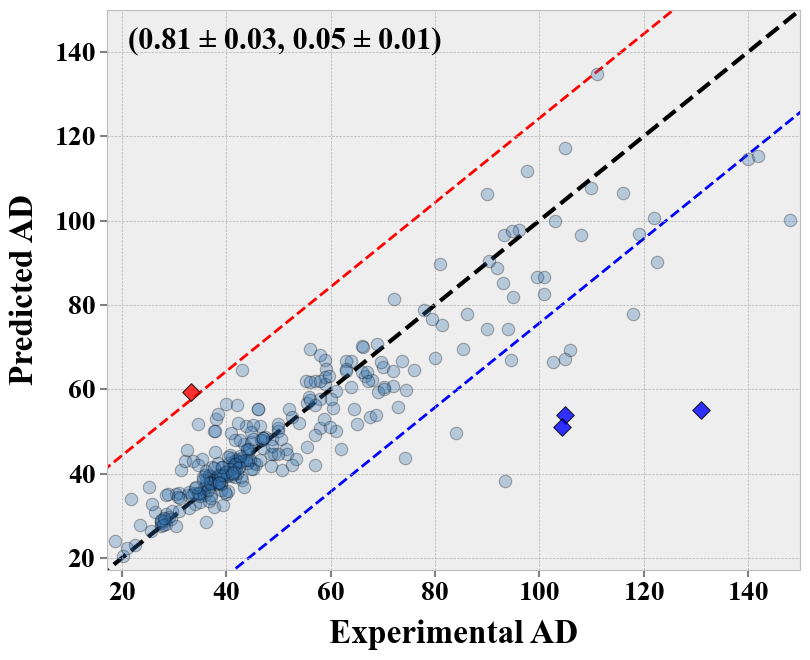

In [13]:
# 计算误差
errors = np.abs(all_predictions - all_actuals)

# 按误差降序排序索引（最大误差在最后）
sorted_idx = np.argsort(errors)

# 指定你要高亮的“误差排名”
selected_ranks = [0, 2, 3, 14] 

# 获取对应的点索引（去重）
highlight_idx = list({sorted_idx[-(r + 1)] for r in selected_ranks})

# 其他点索引
others_idx = np.setdiff1d(np.arange(len(all_actuals)), highlight_idx)

# 构建理想线
sigma = np.std(all_actuals)
# 构建理想线的x和y值
min_val = min(all_actuals.min(), all_predictions.min())
max_val = max(all_actuals.max(), all_predictions.max())
# 设置理想线和偏差带用的横坐标范围，覆盖整个图像范围
x_vals = np.linspace(min_val - 20, max_val + 20, 100)
y_vals = x_vals
ci_upper = y_vals + 1.0 * sigma
ci_lower = y_vals - 1.0 * sigma

# 绘图
plt.figure(figsize=(8.5, 7))
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 20
plt.style.use('bmh')

# 偏差带线和理想线
plt.plot(x_vals, ci_upper, color='red', linestyle='--', linewidth=2, zorder=1, label='±1.5σ upper')
plt.plot(x_vals, ci_lower, color='blue', linestyle='--', linewidth=2, zorder=1, label='±1.5σ lower')
plt.plot(x_vals, y_vals, 'k--', lw=3, zorder=1, label='Ideal: y = x')

# 画其他点（不在top3）
plt.scatter(all_actuals[others_idx], all_predictions[others_idx],  
            alpha=0.3, marker='o', color="#3574B1", 
            edgecolors='black', linewidths=0.8, s=80, zorder=2)
# 分别画 highlight_idx 中在上方和下方的点
existing_labels = set()
for i in highlight_idx:
    if all_predictions[i] > all_actuals[i]:
        color = 'red'
        label = 'Top error (above)'
    else:
        color = '#0000FF'
        label = 'Top error (below)'

    # 避免图例重复
    label = label if label not in existing_labels else None
    if label:
        existing_labels.add(label)

    plt.scatter(all_actuals[i], all_predictions[i],
                color=color, marker='D', edgecolors='black', alpha=0.8,
                linewidths=0.8, s=80, zorder=3, label=label)
# R² 和 RMSE 注释
plt.text(0.03, 0.93, f'({result["r2_val"]}, {result["mae_val"]})',
         fontsize=22, transform=plt.gca().transAxes)

# 标签和样式
plt.xlabel('Experimental AD', weight='bold', fontsize=24, labelpad=10)
plt.ylabel('Predicted AD', weight='bold', fontsize=24, labelpad=10)
plt.xticks(fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')
plt.tick_params(axis='both', which='both', direction='out', length=5, width=1.5,
                color='gray', bottom=True, top=False, left=True, right=False)

# 坐标范围一致
min_val = min(all_actuals.min(), all_predictions.min())
max_val = max(all_actuals.max(), all_predictions.max())
plt.xlim(min_val - 1.5, max_val + 2)
plt.ylim(min_val - 1.5, max_val + 2)

plt.tight_layout()
plt.savefig(os.path.join(folder_path, 'AD-预测结果.png'), dpi=600)
plt.show()


In [ ]:
df_errors = pd.DataFrame({
    'Index': all_indices,
    'Actual': all_actuals,
    'Predicted': all_predictions
})
df_errors['Residuals'] = df_errors['Actual'] - df_errors['Predicted']
df_errors['Abs_Residuals'] = np.abs(df_errors['Residuals'])

# 排序
df_sorted = df_errors.sort_values(by='Abs_Residuals', ascending=False)
df_sorted.head(30)

,Index,Actual,Predicted,Residuals,Abs_Residuals
210,47,131.00,55.021076,75.978924,75.978924
167,204,93.50,38.376822,55.123178,55.123178
239,131,104.30,51.053551,53.246449,53.246449
237,129,105.00,54.027910,50.972090,50.972090
84,259,148.00,100.148312,47.851688,47.851688
190,265,118.00,77.780082,40.219918,40.219918
243,149,105.00,67.213210,37.786790,37.786790
216,54,106.00,69.265628,36.734372,36.734372
47,119,102.56,66.463264,36.096736,36.096736
208,43,84.00,49.719422,34.280578,34.280578


In [18]:
df_top_actual = df.loc[df_sorted['Index'].head(30)]
df_top_actual

,DIPOCE,DI_NCO,PO_HV,PO_f,BA_Code,BA_Mn,PO_Phr,BA_Phr,FS_Phr,Cata_Phr,...,M_loss,Yield,R,CHS,A_Mix_t,AB_Mix_t,Q,Cata_Code,MCS,AD(kg/m3)
47,110000000,31.2500,450.000000,4.498111,1000.0,18.000000,77.869976,1.491281,1.557400,3.114799,...,3.806977,97.932110,1.0500,56.935369,15.00,12.37,0.00000,100100,311.290,131.00
204,100010000,31.4000,495.000000,6.000000,1000.0,18.000000,84.434500,1.688690,0.422173,1.477604,...,4.127909,97.804572,1.3000,54.219791,94.05,10.00,336.00000,100000,103.000,93.50
131,100101001,31.2000,252.342011,3.979733,1001.0,48.042145,95.617287,22.769917,1.955561,3.964800,...,25.719548,89.019482,1.1000,46.935000,11.00,14.00,0.00000,11010,756.340,104.30
129,110001001,31.2000,502.876343,5.084942,1001.0,43.532926,56.281459,1.623665,1.539496,1.432050,...,3.224009,98.073049,1.1000,62.830982,11.00,14.00,0.00000,11010,435.027,105.00
259,110000010,31.0000,450.000000,3.000000,1000.0,18.000000,56.497175,0.225989,1.186441,0.225989,...,0.552417,99.658000,1.0500,63.898917,120.00,30.00,48.00000,100000,150.000,148.00
265,1010000000,30.8000,440.000000,3.000000,0.0,0.000000,84.745763,0.000000,1.694915,0.423729,...,0.000000,100.000000,1.1000,54.128440,311.55,10.00,1128.00000,100000,367.000,118.00
149,110000000,31.2500,300.000000,2.000000,1.0,148.100000,126.000000,10.600000,1.900000,1.000000,...,10.567937,95.589559,1.1000,44.200000,528.00,30.00,0.00000,100000,352.000,105.00
54,100100000,31.2500,431.860292,3.521546,1000.0,18.000000,68.060338,11.152255,2.200507,3.588869,...,20.811240,96.281976,1.0500,47.090340,15.00,15.46,0.00000,100100,370.000,106.00
119,100100000,31.5000,444.200000,4.338506,1000.0,18.000000,84.331087,1.830000,1.601058,1.191693,...,4.468820,98.458250,1.0500,35.400000,120.00,10.00,561.60000,11000,216.477,102.56
43,111000000,32.6000,408.046904,4.777913,1000.0,18.000000,79.772169,1.800000,1.600000,2.000000,...,4.342105,98.168193,1.1000,54.400000,10.00,10.00,18.50000,101000,254.250,84.00


In [16]:
df = pd.read_csv("ADlog_填充.csv")
X = df.drop(["AD(kg/m3)"], axis=1)
# 创建一个SHAP解释器
explainer = shap.Explainer(model)
shap_values = explainer(X)
shap_values
expected_value = explainer.expected_value
expected_value

np.float64(1.671981428330693)

In [17]:
import shap
import os
import matplotlib.pyplot as plt

# 设置字体和样式
plt.rcParams["font.family"] = "Times New Roman"
plt.style.use('default')

# 创建主图
fig, ax1 = plt.subplots(figsize=(25, 8), dpi=1200)

# 蜂巢图（dot plot）
feature_names = [name.replace("f(H2O)", r"f(H$_2$O)") for name in X.columns]
shap.summary_plot(shap_values, X, feature_names=feature_names, plot_type="dot", show=False, color_bar=False, max_display=19)
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # 调整位置为主图 ax1
ax1 = plt.gca()

# 顶部条形图（bar plot）
ax2 = ax1.twiny()
shap.summary_plot(shap_values, X, feature_names=feature_names, plot_type="bar", show=False, max_display=19)
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # 确保对齐
for bar in ax2.patches:
    # bar.set_facecolor("skyblue")
    bar.set_alpha(0.2)

# 添加灰色参考线
ax2.axhline(y=19, color='black', linestyle='-', linewidth=2)

# 坐标轴标签设置,新罗马字体
ax1.set_xlabel('Shapley Value Contribution', fontsize=22, labelpad=10, weight='bold', fontname='Times New Roman')
ax1.set_ylabel('Features', fontsize=22, labelpad=10, weight='bold', fontname='Times New Roman')

ax2.set_xlabel('Mean (|Shapley Value|)', fontsize=22, labelpad=10, weight='bold', fontname='Times New Roman')
ax2.xaxis.set_label_position('top')
ax2.xaxis.tick_top()

# 设置刻度字体大小和粗细
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontsize(18)
    label.set_fontweight('bold')
    label.set_fontname('Times New Roman')

for label in ax2.get_xticklabels():
    label.set_fontsize(18)
    label.set_fontweight('bold')
    label.set_fontname('Times New Roman')
# 边框
for spine in ['left',  'bottom']:
    ax1.spines[spine].set_visible(True)
    ax1.spines[spine].set_edgecolor('black')
    ax1.spines[spine].set_linewidth(1.5)

# 刻度线
ax1.tick_params(axis='both', direction='out', colors='black', width=1.5, length=5)
ax2.tick_params(axis='x', direction='out', colors='black', width=1.5, length=5)
# 设定主坐标轴的x轴范围（根据你的数据调整）
ax1.set_xlim(-0.08, 0.12)
ax2.set_xlim(0, 0.03)
ax1.set_xticks(np.linspace(-0.08, 0.12, 6))
ax2.set_xticks(np.linspace(0, 0.033, 4))
# 调整排版，保存并展示
plt.tight_layout()
plt.savefig(os.path.join(folder_path, 'AD_SHAP.png'), dpi=600, bbox_inches='tight')
plt.show()
